# Torpedo Firing Doctrine Comparison

This notebook compares focused, submarine-centric snapshots for three fan-mode firing doctrines:

- `longitudinal`: no final gyro divergence; same final heading for every torpedo. In the real simulator this is a steady-boat timing doctrine and is treated as rare/nonstandard for convoy attacks.
- `uniform_divergent`: evenly spaced final gyro offsets across a total `spread_rad`; this is the standard convoy doctrine.
- `explicit_divergent`: authored per-torpedo final gyro offsets; this is a manual/advanced convoy doctrine.

Structure:
- one large plot cell per doctrine / motion case
- the snapshot is taken at the end of the firing cycle plus a short post-launch window
- a compact text table is printed under each plot with launch positions, launch times, and final headings
- short markdown note cells are provided after the paired cases so you can record observations after running the notebook
- plots save by default to `/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison`

Plot convention:
- The U-boat is shown at a common end-of-firing-cycle snapshot.
- Torpedo paths are drawn out to a capped 150 m post-launch run distance so salvo members keep equal displayed range.
- The longitudinal notebook panels remain intentionally stylized visualization aids so timing spread stays legible.
- The real simulator semantics are steadier: all doctrines assume a steady firing course during the salvo unless the stability guardrails are deliberately disabled.


In [1]:
#Imports
from __future__ import annotations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from convoy_sim.attack_profiles import AttackProfile
from convoy_sim.entities import Torpedo
from convoy_sim.realism import UBoatMotionPlan
from convoy_sim.viz_attack import (format_torpedo_heading_table, plot_torpedo_doctrine_snapshot, sample_u_boat_track,)

plt.rcParams["figure.facecolor"] = "lightgrey"
plt.rcParams["axes.facecolor"] = "#06768d"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 11


In [2]:
BASE_BEARING_RAD = float(np.pi / 2.0)
U_BOAT_START = np.array([0.0, 0.0], dtype=float)
U_BOAT_SPEED_MPS = 2.0
TORPEDO_SPEED_MPS = 15.4333
SALVO_INTERVAL_S = 4.0
POST_FIRE_WINDOW_S = 18.0
VIEW_BOUNDS = (-50.0, 50.0, -25.0, 150.0)
UNIFORM_SPREAD_RAD = float(np.deg2rad(18.0))
EXPLICIT_OFFSETS_RAD = tuple(np.deg2rad(np.array([-12.0, -3.0, 2.0, 10.0], dtype=float)))
TORPEDO_TRAVEL_DISTANCE_M = 125
TORPEDO_RUN_TIME_S = TORPEDO_TRAVEL_DISTANCE_M / TORPEDO_SPEED_MPS
LONGITUDINAL_STEP_DEG = 3.0
LONGITUDINAL_TURN_RATE_RAD_S = float(np.deg2rad(LONGITUDINAL_STEP_DEG) / SALVO_INTERVAL_S)
LONGITUDINAL_STATIC_OFFSETS_DEG = np.array([4.5, 1.5, -1.5, -4.5], dtype=float)
SAVE_PLOTS = True
OUTPUT_DIR = Path("/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison")

DOCTRINE_TITLES = {
    "longitudinal": "Longitudinal / Timing-Only",
    "uniform_divergent": "Uniform Divergent",
    "explicit_divergent": "Explicit Divergent",
}


def _motion_payload(profile: AttackProfile) -> dict[str, object]:
    initial_heading = float(profile.u_boat_initial_heading_rad)
    if profile.uses_legacy_bearing_compat():
        initial_heading = float(profile.requested_attack_bearing_rad())
    return {
        "mode": profile.u_boat_mode,
        "initial_position": [float(profile.u_pos[0]), float(profile.u_pos[1])],
        "initial_heading_rad": initial_heading,
        "initial_speed_mps": float(profile.u_boat_initial_speed_mps),
        "launch_time_s": float(profile.u_boat_launch_time_s),
        "turn_rate_limit_rad_s": profile.u_boat_turn_rate_limit_rad_s,
        "accel_limit_mps2": profile.u_boat_accel_limit_mps2,
        "legs": [
            {"duration_s": float(a), "heading_rad": float(b), "speed_mps": float(c)}
            for (a, b, c) in profile.u_boat_motion_legs
        ],
    }


def build_profile(doctrine: str, *, moving: bool) -> AttackProfile:
    kwargs: dict[str, object] = {
        "profile_id": f"{doctrine[:3].upper()}_{'MOV' if moving else 'STA'}",
        "name": f"{doctrine}_{'moving' if moving else 'static'}",
        "mode": "fan",
        "u_pos": tuple(U_BOAT_START),
        "n": 4,
        "speed": TORPEDO_SPEED_MPS,
        "max_run_time": TORPEDO_RUN_TIME_S,
        "base_bearing_rad": BASE_BEARING_RAD,
        "spread_rad": 0.0 if doctrine == "longitudinal" else UNIFORM_SPREAD_RAD,
        "spread_doctrine": doctrine,
        "launch_delay_s": 0.0,
        "salvo_interval_s": SALVO_INTERVAL_S,
        "u_boat_mode": "moving" if moving else "static",
        "u_boat_initial_heading_rad": BASE_BEARING_RAD,
        "u_boat_initial_speed_mps": U_BOAT_SPEED_MPS if moving else 0.0,
        "u_boat_launch_time_s": 0.0,
        "launch_from": "center",
        "max_bow_offset_deg": 20.0,
        "gyro_straight_run_m": 5.0,
        "require_stable_u_boat_during_salvo": True,
    }
    if moving:
        kwargs["u_boat_motion_legs"] = ((120.0, BASE_BEARING_RAD, U_BOAT_SPEED_MPS),)
    if doctrine == "explicit_divergent":
        kwargs["spread_rad"] = 0.0
        kwargs["per_torpedo_heading_offsets_rad"] = EXPLICIT_OFFSETS_RAD
    return AttackProfile(**kwargs)


def motion_plan_for_profile(profile: AttackProfile) -> UBoatMotionPlan:
    return UBoatMotionPlan.from_dict(_motion_payload(profile), fallback_u_pos=profile.u_pos)


def snapshot_time_for_profile(profile: AttackProfile) -> float:
    last_launch = float(profile.u_boat_launch_time_s + profile.launch_delay_s + (profile.n - 1) * profile.salvo_interval_s)
    return last_launch + POST_FIRE_WINDOW_S


def longitudinal_state_at(t: float, *, moving: bool) -> tuple[np.ndarray, float, float]:
    t = max(0.0, float(t))
    omega = -LONGITUDINAL_TURN_RATE_RAD_S
    heading = float(BASE_BEARING_RAD + omega * t)
    if not moving:
        return np.asarray(U_BOAT_START, dtype=float), heading, 0.0
    if abs(omega) <= 1e-12:
        direction = np.asarray([np.cos(BASE_BEARING_RAD), np.sin(BASE_BEARING_RAD)], dtype=float)
        pos = np.asarray(U_BOAT_START, dtype=float) + direction * U_BOAT_SPEED_MPS * t
        return pos, heading, U_BOAT_SPEED_MPS
    x = float(U_BOAT_START[0] + (U_BOAT_SPEED_MPS / omega) * (np.sin(BASE_BEARING_RAD + omega * t) - np.sin(BASE_BEARING_RAD)))
    y = float(U_BOAT_START[1] - (U_BOAT_SPEED_MPS / omega) * (np.cos(BASE_BEARING_RAD + omega * t) - np.cos(BASE_BEARING_RAD)))
    return np.array([x, y], dtype=float), heading, U_BOAT_SPEED_MPS


def build_longitudinal_case(*, moving: bool) -> tuple[AttackProfile, list[Torpedo], np.ndarray | None, np.ndarray, float, float]:
    profile = build_profile("longitudinal", moving=moving)
    launch_times = [idx * SALVO_INTERVAL_S for idx in range(profile.n)]
    torpedoes: list[Torpedo] = []
    for idx, launch_t in enumerate(launch_times, start=1):
        launch_pos, sub_heading, _ = longitudinal_state_at(launch_t, moving=moving)
        if moving:
            torp_heading = float(sub_heading)
        else:
            torp_heading = float(BASE_BEARING_RAD + np.deg2rad(float(LONGITUDINAL_STATIC_OFFSETS_DEG[idx - 1])))
        torpedoes.append(
            Torpedo(
                id=f"L{idx:02d}",
                launch_position=np.asarray(launch_pos, dtype=float),
                speed=TORPEDO_SPEED_MPS,
                heading_rad=float(torp_heading),
                max_run_time=TORPEDO_RUN_TIME_S,
                launch_delay=float(launch_t),
                launch_heading_rad=float(torp_heading),
                gyro_turn_distance_m=0.0,
            )
        )
    snapshot_time = float(launch_times[-1] + POST_FIRE_WINDOW_S)
    u_pos, u_heading, _ = longitudinal_state_at(snapshot_time, moving=moving)
    if moving:
        times = np.linspace(0.0, snapshot_time, 200, dtype=float)
        u_track = np.asarray([longitudinal_state_at(t, moving=True)[0] for t in times], dtype=float)
    else:
        u_track = None
        u_heading = float(BASE_BEARING_RAD)
    return profile, torpedoes, u_track, np.asarray(u_pos, dtype=float), float(u_heading), snapshot_time


def _save_figure(fig: plt.Figure, stem: str, *, save: bool) -> Path | None:
    if not save:
        return None
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(out_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved plot: {out_path}")
    return out_path


def show_case(doctrine: str, *, moving: bool, save: bool = SAVE_PLOTS) -> tuple[AttackProfile, list[Torpedo]]:
    if doctrine == "longitudinal":
        profile, torpedoes, u_track, u_pos, u_heading, snapshot_time = build_longitudinal_case(moving=moving)
    else:
        profile = build_profile(doctrine, moving=moving)
        torpedoes = profile.build_torpedoes(np.random.default_rng(7))
        motion_plan = motion_plan_for_profile(profile)
        snapshot_time = snapshot_time_for_profile(profile)
        u_pos, u_heading, _ = motion_plan.state_at(snapshot_time)
        u_track = None
        if moving:
            u_track = sample_u_boat_track(motion_plan, 0.0, snapshot_time, n_points=200)

    fig, ax = plt.subplots(figsize=(8.2, 8.6), facecolor="lightgrey")
    state_label = "Moving" if moving else ("Static / Pivot" if doctrine == "longitudinal" else "Static")
    plot_torpedo_doctrine_snapshot(
        torpedoes,
        snapshot_time_s=snapshot_time,
        ax=ax,
        title=f"{DOCTRINE_TITLES[doctrine]} | {state_label} U-boat \n",
        u_boat_track=u_track,
        u_boat_position=np.asarray(u_pos, dtype=float),
        u_boat_heading_rad=float(u_heading),
        centerline_bearing_rad=BASE_BEARING_RAD,
        show_centerline=False,
        show_launch_points=True,
        view_bounds=VIEW_BOUNDS,
        figure_facecolor="lightgrey",
        axes_facecolor="#06768d",
        path_color="black",
        launch_point_color="#b00020",
        launch_point_size=50.0,
        torpedo_linewidth=0.8,
        show_full_torpedo_run=True,
        u_boat_marker=".",
        u_boat_size=75,
    )
    ax.set_xticks(np.arange(VIEW_BOUNDS[0], VIEW_BOUNDS[1] + 1e-9, 25.0))
    ax.set_yticks(np.arange(VIEW_BOUNDS[2], VIEW_BOUNDS[3] + 1e-9, 25.0))
    _save_figure(fig, f"{doctrine}_{'moving' if moving else 'static'}", save=save)
    plt.show()

    print(f"Snapshot time: {snapshot_time:.1f}s")
    print(format_torpedo_heading_table(torpedoes))
    return profile, torpedoes


def show_summary_grid(*, save: bool = SAVE_PLOTS) -> None:
    order = [
        ("longitudinal", False),
        ("longitudinal", True),
        ("uniform_divergent", False),
        ("uniform_divergent", True),
        ("explicit_divergent", False),
        ("explicit_divergent", True),
    ]
    fig, axes = plt.subplots(3, 2, figsize=(12.5, 17.5), facecolor="lightgrey")
    for ax, (doctrine, moving) in zip(axes.flat, order):
        if doctrine == "longitudinal":
            profile, torpedoes, u_track, u_pos, u_heading, snapshot_time = build_longitudinal_case(moving=moving)
        else:
            profile = build_profile(doctrine, moving=moving)
            torpedoes = profile.build_torpedoes(np.random.default_rng(7))
            motion_plan = motion_plan_for_profile(profile)
            snapshot_time = snapshot_time_for_profile(profile)
            u_pos, u_heading, _ = motion_plan.state_at(snapshot_time)
            u_track = sample_u_boat_track(motion_plan, 0.0, snapshot_time, n_points=200) if moving else None
        state_label = "Moving" if moving else ("Static / Pivot" if doctrine == "longitudinal" else "Static")
        plot_torpedo_doctrine_snapshot(
            torpedoes,
            snapshot_time_s=snapshot_time,
            ax=ax,
            title=f"{DOCTRINE_TITLES[doctrine]} | {state_label} \n",
            u_boat_track=u_track,
            u_boat_position=np.asarray(u_pos, dtype=float),
            u_boat_heading_rad=float(u_heading),
            centerline_bearing_rad=BASE_BEARING_RAD,
            show_centerline=False,
            show_launch_points=True,
            view_bounds=VIEW_BOUNDS,
            axes_facecolor="#06768d",
            path_color="black",
            launch_point_color="#b00020",
            launch_point_size=50.0,
            torpedo_linewidth=0.8,
            show_full_torpedo_run=True,
            u_boat_marker=".",
            u_boat_size=75,
        )
        ax.set_xticks(np.arange(VIEW_BOUNDS[0], VIEW_BOUNDS[1] + 1e-9, 25.0))
        ax.set_yticks(np.arange(VIEW_BOUNDS[2], VIEW_BOUNDS[3] + 1e-9, 25.0))
    fig.tight_layout()
    _save_figure(fig, "summary_grid", save=save)
    plt.show()


## Longitudinal Doctrine

Interpretation focus:
- In the real simulator, longitudinal doctrine means same final heading with staggered launches while the submarine holds course during the salvo.
- The notebook's static and moving longitudinal panels are intentionally stylized so the timing-only geometry is easier to compare visually.


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/longitudinal_static.png


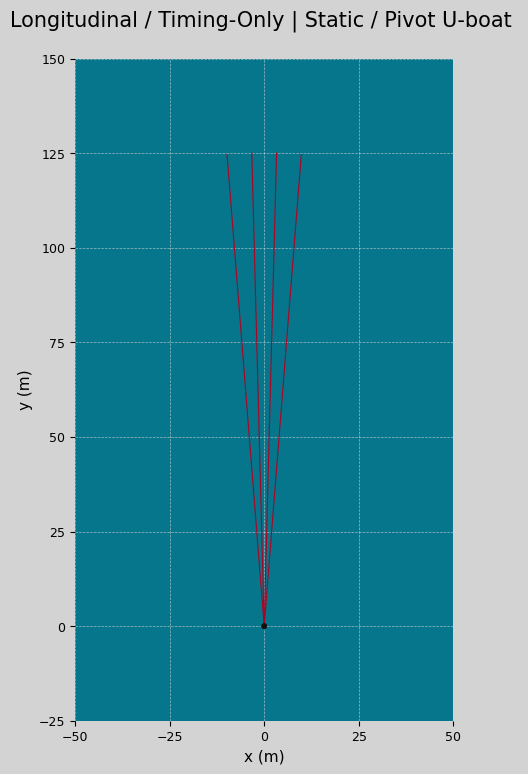

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   L01        0.0         0.0         0.0        94.5       94.5       0.0
   2   L02        4.0         0.0         0.0        91.5       91.5       0.0
   3   L03        8.0         0.0         0.0        88.5       88.5       0.0
   4   L04       12.0         0.0         0.0        85.5       85.5       0.0


In [3]:
profile_long_static, torps_long_static = show_case('longitudinal', moving=False)


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/longitudinal_moving.png


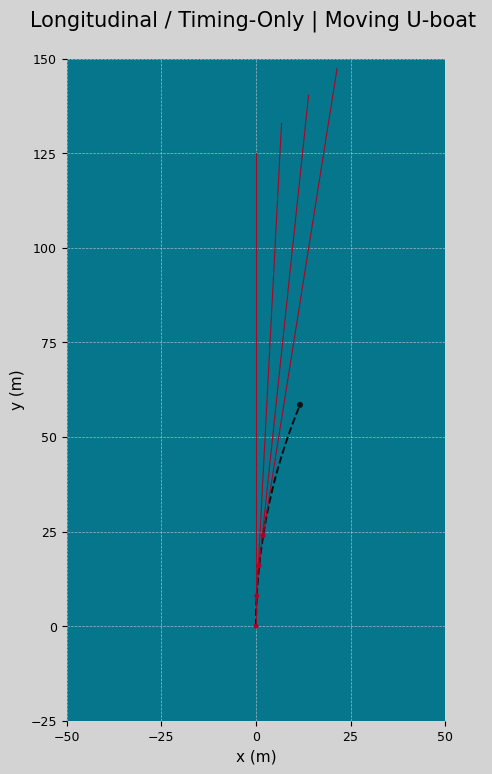

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   L01        0.0         0.0         0.0        90.0       90.0       0.0
   2   L02        4.0         0.2         8.0        87.0       87.0       0.0
   3   L03        8.0         0.8        16.0        84.0       84.0       0.0
   4   L04       12.0         1.9        23.9        81.0       81.0       0.0


In [4]:
profile_long_moving, torps_long_moving = show_case('longitudinal', moving=True)


### Longitudinal Notes

-

## Uniform Divergent Doctrine

Interpretation focus:
- Compare this against the longitudinal case with the same timing and boat motion.
- The final headings should form a symmetric fan around the vertical centerline.


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/uniform_divergent_static.png


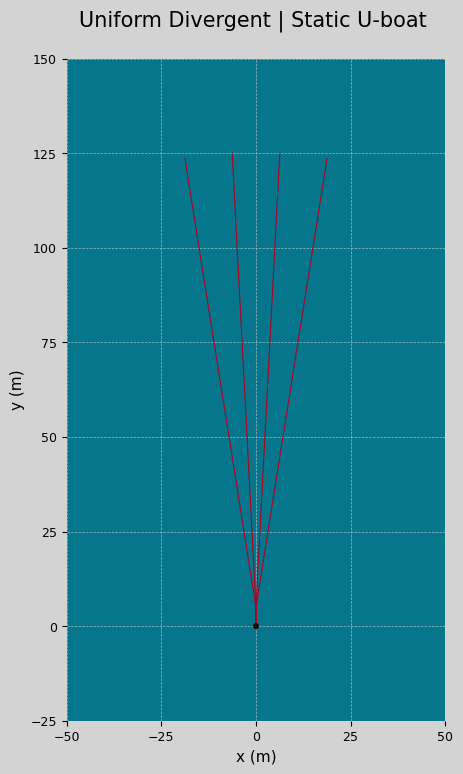

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0         0.0        90.0       81.0      -9.0
   2   F02        4.0         0.0         0.0        90.0       87.0      -3.0
   3   F03        8.0         0.0         0.0        90.0       93.0       3.0
   4   F04       12.0         0.0         0.0        90.0       99.0       9.0


In [5]:
profile_uniform_static, torps_uniform_static = show_case('uniform_divergent', moving=False)


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/uniform_divergent_moving.png


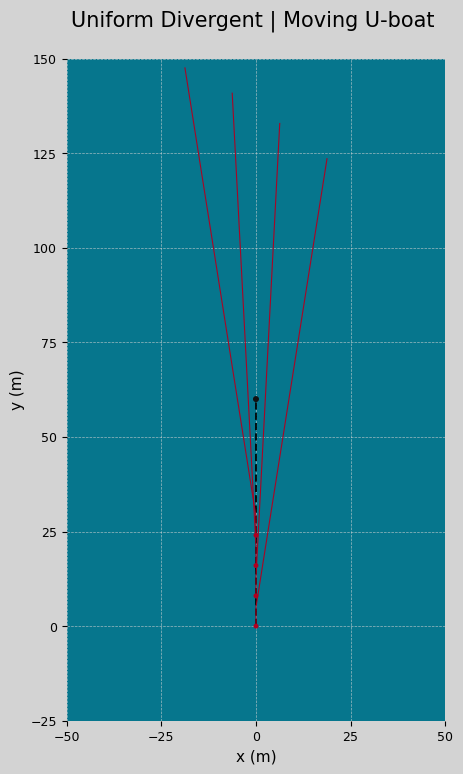

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0         0.0        90.0       81.0      -9.0
   2   F02        4.0         0.0         8.0        90.0       87.0      -3.0
   3   F03        8.0         0.0        16.0        90.0       93.0       3.0
   4   F04       12.0         0.0        24.0        90.0       99.0       9.0


In [6]:
profile_uniform_moving, torps_uniform_moving = show_case('uniform_divergent', moving=True)


### Uniform Divergent Notes

-


## Explicit Divergent Doctrine

Interpretation focus:
- This case uses authored, non-uniform per-torpedo offsets.
- The visual fan should be asymmetric relative to the vertical centerline.


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/explicit_divergent_static.png


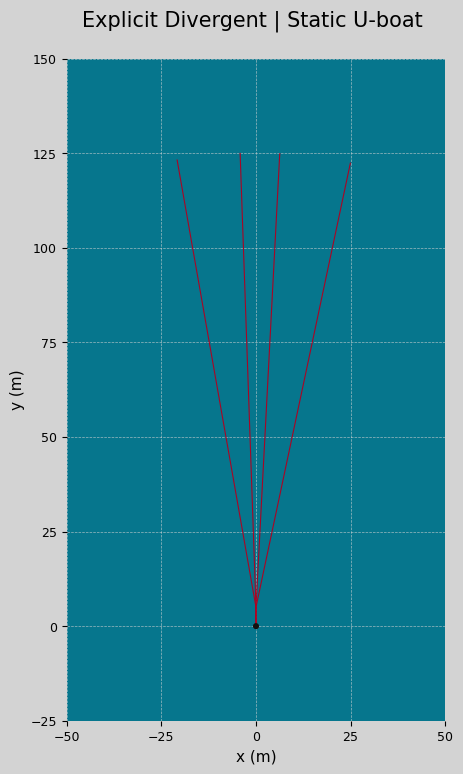

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0         0.0        90.0       78.0     -12.0
   2   F02        4.0         0.0         0.0        90.0       87.0      -3.0
   3   F03        8.0         0.0         0.0        90.0       92.0       2.0
   4   F04       12.0         0.0         0.0        90.0      100.0      10.0


In [7]:
profile_explicit_static, torps_explicit_static = show_case('explicit_divergent', moving=False)


Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/explicit_divergent_moving.png


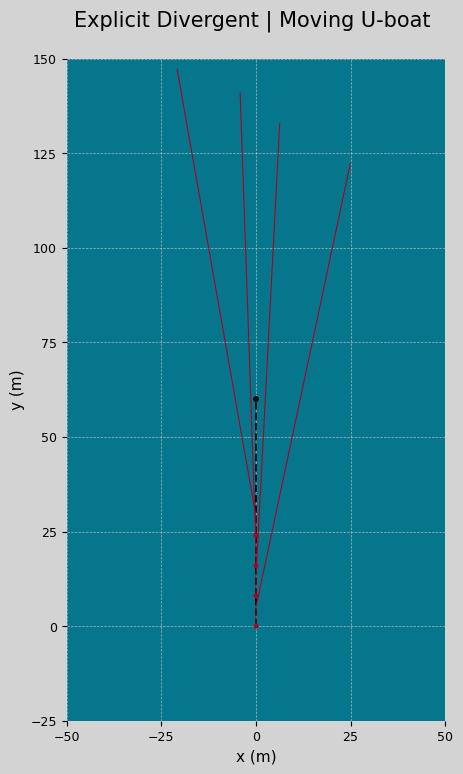

Snapshot time: 30.0s
shot    id t_launch_s  launch_x_m  launch_y_m  launch_deg  final_deg  gyro_deg
   1   F01        0.0         0.0         0.0        90.0       78.0     -12.0
   2   F02        4.0         0.0         8.0        90.0       87.0      -3.0
   3   F03        8.0         0.0        16.0        90.0       92.0       2.0
   4   F04       12.0         0.0        24.0        90.0      100.0      10.0


In [8]:
profile_explicit_moving, torps_explicit_moving = show_case('explicit_divergent', moving=True)


### Explicit Divergent Notes

-

### All Six Side-by-Side Plots:

Saved plot: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/torpedo_firing_doctrine_comparison/summary_grid.png


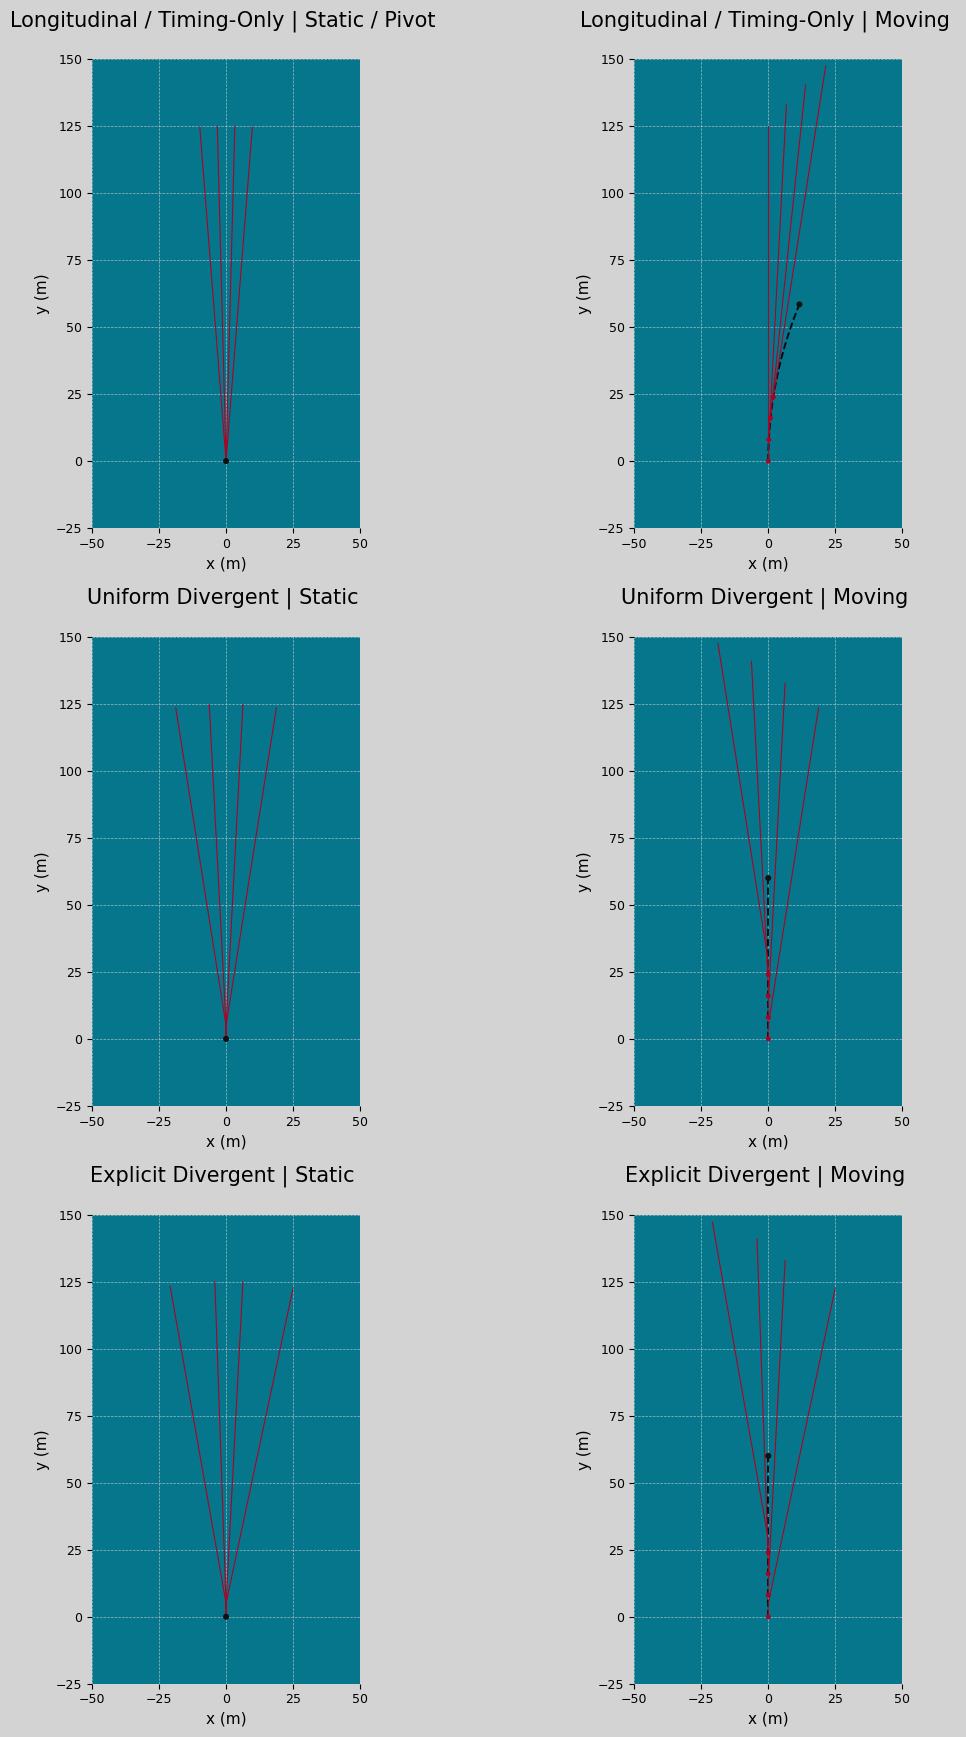

In [9]:
show_summary_grid()